<h1>1.Business Understanding</h1>
<h2>A.Latar Belakang(Background):</h2>
<p>Industri penerbangan dituntut untuk memiliki standar keselamatan yang sangat tinggi(zero accident). Meskipun kecelakaan pesawat relatif jarang  terjadi dibandingkan moda transportasi lain,dampak yang ditimbulkan(korban jiwa dan kerugian material) sangatlah masif.<p>

<p>Selama ini, investigasi kecelakaan dilakukan secara manual dan pendekatan berdasarkan kasus kasus tertentu oleh lembaga resmi(seperti KNKT atau NTSB). Dengan menggunakan data historis kecelakaan pesawat terbang, pendekatan Machine Learning dapat membantu manusia dalam mengidentifikasi pola tersembunyi, melihat faktor kontributor utama(apakah dari faktor manusia,kegagalan mekanis, atau cuaca), serta memprediksi tingkat keparahan insiden di masa depan. </p>

<h2>B.Tujuan Bisnis</h2>

<ul>
  <li>Mengidentifikasi Faktor Dominan: Mengetahui fitur atau variabel apa yang paling sering memicu terjadinya kecelakaan pesawat (misalnya: fase penerbangan, cuaca, usia pesawat, atau tipe mesin).</li>
  <li>Preventif & Mitigasi Risiko: Memberikan rekomendasi atau insight kepada maskapai, regulator, atau lembaga keselamatan untuk memperketat regulasi pada faktor-faktor yang paling berisiko tinggi.</li>
  <li>Klasifikasi Keparahan: Membangun sistem yang mampu mengklasifikasikan tingkat keparahan kecelakaan (misalnya: Fatal, Serious, Minor, atau No Injury) berdasarkan kondisi-kondisi tertentu saat insiden terjadi.</li>
</ul>


<h1>C. Penilaian Situasi</h1>

<ul>
  <li>Ketersediaan Data: Menggunakan data historis kecelakaan pesawat (seperti dataset dari NTSB, Aviation Safety Network, atau Kaggle).</li>
  <li>Kebutuhan Data: Data harus mencakup informasi cuaca, detail pesawat (manufaktur, model, mesin), informasi penerbangan (fase take-off, cruise, landing), lokasi, serta jumlah korban/kerusakan.</li>
  <li>Kendala (Constraints): Data kecelakaan pesawat sering kali memiliki masalah imbalanced data (kasus fatal biasanya lebih sedikit dibanding insiden minor, atau sebaliknya tergantung penyusunan dataset), serta banyaknya data teks tak terstruktur (kronologi kejadian) yang memerlukan penanganan khusus jika ingin digunakan..</li>
</ul>


<h1></h1>

<h1>D. Tujuan Data Mining (Data Mining Goals)</h1>

<ul>
  <li>
    <strong>Tugas Klasifikasi (Supervised Learning):</strong> 
    Membangun model prediksi untuk mengelompokkan tingkat keparahan kecelakaan (Multi-class Classification) menggunakan tiga algoritma:
    <ul>
      <li><strong>Random Forest:</strong> Baik dalam menangani data non-linear dan memberikan interpretasi feature importance.</li>
      <li><strong>XGBoost:</strong> Sangat kuat dalam akurasi dan menangani pola data yang kompleks secara efisien.</li>
      <li><strong>Support Vector Machine (SVM):</strong> Efektif untuk ruang dimensi tinggi dan mencari hyperplane pemisah terbaik.</li>
    </ul>
  </li>
  <li>
    <strong>Analisis Fitur (Feature Importance):</strong> Mengekstrak bobot variabel dari model (terutama Random Forest dan XGBoost) untuk menentukan faktor yang paling dominan menyebabkan kecelakaan.
  </li>
  <li>
    <strong>Evaluasi Model:</strong> Membandingkan performa ketiga algoritma menggunakan metrik yang tepat 
    (Akurasi, Precision, Recall, dan F1-Score — sangat penting memperhatikan F1-Score karena potensi imbalanced data).
  </li>
</ul>


<h1>E. Rencana Proyek (Project Plan)</h1>

<ul>
  <li>
    <strong>Business Understanding:</strong> Sesi kita saat ini.
  </li>
  <li>
    <strong>Data Understanding:</strong> 
    <ul>
      <li>Eksplorasi data awal (EDA)</li>
      <li>Cek distribusi kelas keparahan</li>
      <li>Cek missing values</li>
    </ul>
  </li>
  <li>
    <strong>Data Preparation:</strong> 
    <ul>
      <li>Cleaning</li>
      <li>Handling missing values</li>
      <li>Encoding variabel kategorikal</li>
      <li>Scaling (terutama untuk SVM)</li>
      <li>Handling imbalanced data (misal dengan SMOTE jika diperlukan)</li>
    </ul>
  </li>
  <li>
    <strong>Modeling:</strong> 
    <ul>
      <li>Melatih algoritma Random Forest, XGBoost, dan SVM</li>
      <li>Melakukan hyperparameter tuning</li>
    </ul>
  </li>
  <li>
    <strong>Evaluation:</strong> Membandingkan performa ketiga model dan menganalisis faktor dominan (feature importance).
  </li>
  <li>
    <strong>Deployment:</strong> (Opsional/Sesuai kebutuhan proyek) 
    <ul>
      <li>Pembuatan laporan</li>
      <li>Visualisasi insight untuk stakeholder</li>
      <li>Integrasi ke dashboard (misalnya menggunakan Streamlit)</li>
    </ul>
  </li>
</ul>


In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time


In [3]:
# Load dataset
df = pd.read_csv('dataset_pesawat_terbang/airline_accidents.csv', encoding='ISO-8859-1', low_memory=False)
print(f"Dimensi data awal: {df.shape}")
#Menampilkan 5 baris pertama
df.head(5)

Dimensi data awal: (150959, 31)


,Event Id,Investigation Type,Accident Number,Event Date,Location,Country,Latitude,Longitude,Airport Code,Airport Name,...,Purpose of Flight,Air Carrier,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Weather Condition,Broad Phase of Flight,Report Publication Date,Unnamed: 30
0,20080125X00106,Accident,SEA08CA056,12/31/2007,"Santa Ana, CA",United States,33.675556,-117.868056,SNA,John Wayne - Orange County,...,Instructional,,,,,2,VMC,LANDING,02/28/2008,
1,20080206X00141,Accident,CHI08WA075,12/31/2007,"Guernsey, United Kingdom",United Kingdom,49.435000,-2.600278,,,...,Unknown,,,,,1,,,02/06/2008,
2,20080129X00122,Accident,CHI08CA057,12/30/2007,"Alexandria, MN",United States,45.866111,-95.394444,AXN,Chandler Field Airport,...,Personal,,,,,1,VMC,TAKEOFF,02/28/2008,
3,20080114X00045,Accident,LAX08FA043,12/30/2007,"Paso Robles, CA",United States,35.542222,-120.522778,PRB,Paso Robles Airport,...,Personal,,1,,,,VMC,MANEUVERING,06/20/2014,
4,20080109X00032,Accident,NYC08FA071,12/30/2007,"Cherokee, AL",United States,34.688611,-87.920000,,,...,Other Work Use,,3,0,0,0,VMC,MANEUVERING,01/15/2009,


In [4]:
df.tail(5)

,Event Id,Investigation Type,Accident Number,Event Date,Location,Country,Latitude,Longitude,Airport Code,Airport Name,...,Purpose of Flight,Air Carrier,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Weather Condition,Broad Phase of Flight,Report Publication Date,Unnamed: 30
150954,24237,,NYC65I0127,,"BRADFORD, PA",United States,,,,,...,,,0,0,0,0,,,,
150955,24243,,LAX78DUJ68,,"WINSLOW, AZ",United States,,,,,...,,,0,0,0,0,,,,
150956,24242,,MIA74DLD77,,"SARASOTA, FL",United States,,,,,...,,,0,0,0,0,,,,
150957,24239,,LAX68F0032,,"SCOTTSDALE, AZ",United States,,,,,...,,,0,0,0,0,,,,
150958,24240,,OAK69A0051,,"LAKEPORT, CA",United States,,,,,...,,,0,0,0,0,,,,


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150959 entries, 0 to 150958
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Event Id                 150959 non-null  str  
 1   Investigation Type       150959 non-null  str  
 2   Accident Number          150959 non-null  str  
 3   Event Date               150959 non-null  str  
 4   Location                 150959 non-null  str  
 5   Country                  150959 non-null  str  
 6   Latitude                 150959 non-null  str  
 7   Longitude                150959 non-null  str  
 8   Airport Code             150959 non-null  str  
 9   Airport Name             150959 non-null  str  
 10  Injury Severity          150959 non-null  str  
 11  Aircraft Damage          150959 non-null  str  
 12  Aircraft Category        150959 non-null  str  
 13  Registration Number      150959 non-null  str  
 14  Make                     150959 non-null  str  

In [6]:
df.describe()

,Event Id,Investigation Type,Accident Number,Event Date,Location,Country,Latitude,Longitude,Airport Code,Airport Name,...,Purpose of Flight,Air Carrier,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Weather Condition,Broad Phase of Flight,Report Publication Date,Unnamed: 30
count,150959,150959,150959,150959,150959,150959,150959,150959,150959,150959,...,150959,150959,150959,150959,150959,150959,150959,150959,150959,150959
unique,150047,3,143310,16138,33888,168,8868,9268,7881,18236,...,23,2317,109,37,58,344,4,13,2418,1
top,20001212X19172,,Unknown,10/02/1966,"ANCHORAGE, AK",United States,,,,,...,,,0,0,0,0,,,,
freq,3,87046,6031,41,828,147351,138985,138995,116096,113581,...,88765,147848,69035,76874,74262,53398,87554,89235,99786,150959


In [7]:
df.shape

(150959, 31)

In [ ]:
# Hilangkan spasi di awal dan akhir teks pada semua kolom kategorikal
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Ubah string kosong, 'nan', atau 'None' menjadi NaN asli Python
df.replace(['', 'nan', 'NaN', 'None'], np.nan, inplace=True)
print("Pembersihan spasi gaib selesai dilakukan di awal.")

C:\Users\Ghally\AppData\Local\Temp\ipykernel_38956\3583597633.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Pembersihan spasi gaib selesai dilakukan di awal.


In [9]:
# 1. Memeriksa missing value asli setelah spasi dihilangkan
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
df_missing = pd.DataFrame({'Total Missing': missing_data, 'Percentage(%)': missing_percent})
print("--- MISSING VALUES YANG SEBENARNYA ---")
print(df_missing[df_missing['Total Missing'] > 0].sort_values(by='Percentage(%)', ascending=False))

# 2. Memeriksa data duplikat
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")

--- MISSING VALUES YANG SEBENARNYA ---
                         Total Missing  Percentage(%)
Unnamed: 30                     150959     100.000000
Air Carrier                     147848      97.939176
Aircraft Category               143206      94.864168
Schedule                        141046      93.433316
Longitude                       138995      92.074669
Latitude                        138985      92.068045
Airport Code                    116096      76.905650
Airport Name                    113616      75.262820
Report Publication Date          99786      66.101392
Number of Engines                89594      59.349890
Broad Phase of Flight            89235      59.112077
Purpose of Flight                88765      58.800734
Aircraft Damage                  88691      58.751714
Engine Type                      88498      58.623865
Weather Condition                87554      57.998529
Investigation Type               87046      57.662014
FAR Description                  56154     

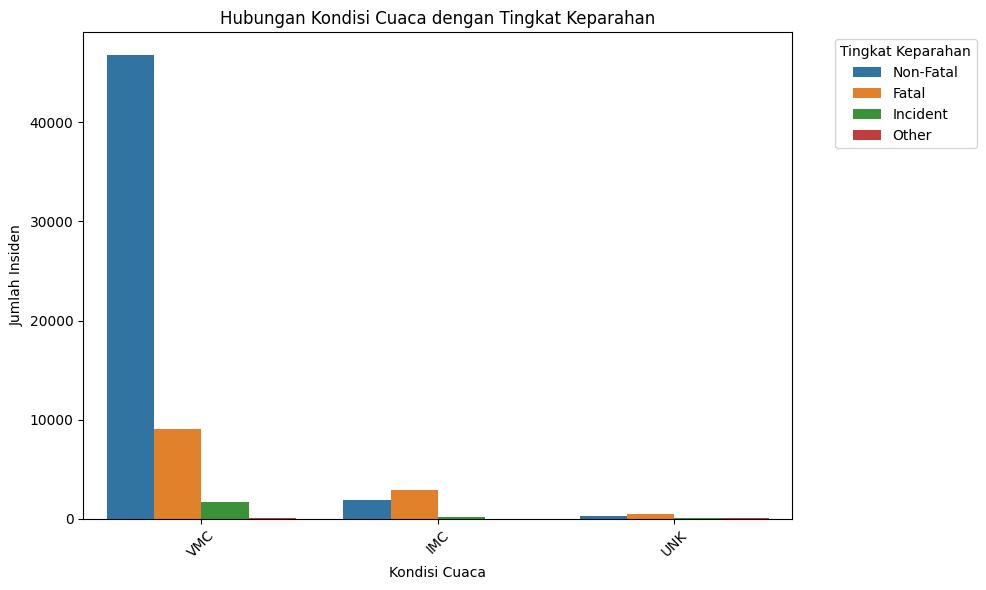

In [10]:
# 1. Fungsi pembersihan target yang aman (case-insensitive)
def clean_injury_severity(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).lower().strip()
    if 'fatal' in val and 'non' not in val:
        return 'Fatal'
    elif 'non' in val and 'fatal' in val:
        return 'Non-Fatal'
    elif 'incident' in val:
        return 'Incident'
    else:
        return 'Other'

df['Injury_Severity_Clean'] = df['Injury Severity'].apply(clean_injury_severity)

# 2. Visualisasi Hubungan Kondisi Cuaca dengan Tingkat Keparahan
plt.figure(figsize=(10, 6))
top_weather = df['Weather Condition'].value_counts().iloc[:5].index

sns.countplot(data=df[df['Weather Condition'].isin(top_weather)], 
              x='Weather Condition', hue='Injury_Severity_Clean', order=top_weather)

plt.title('Hubungan Kondisi Cuaca dengan Tingkat Keparahan')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Insiden')
plt.xticks(rotation=45)
plt.legend(title='Tingkat Keparahan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

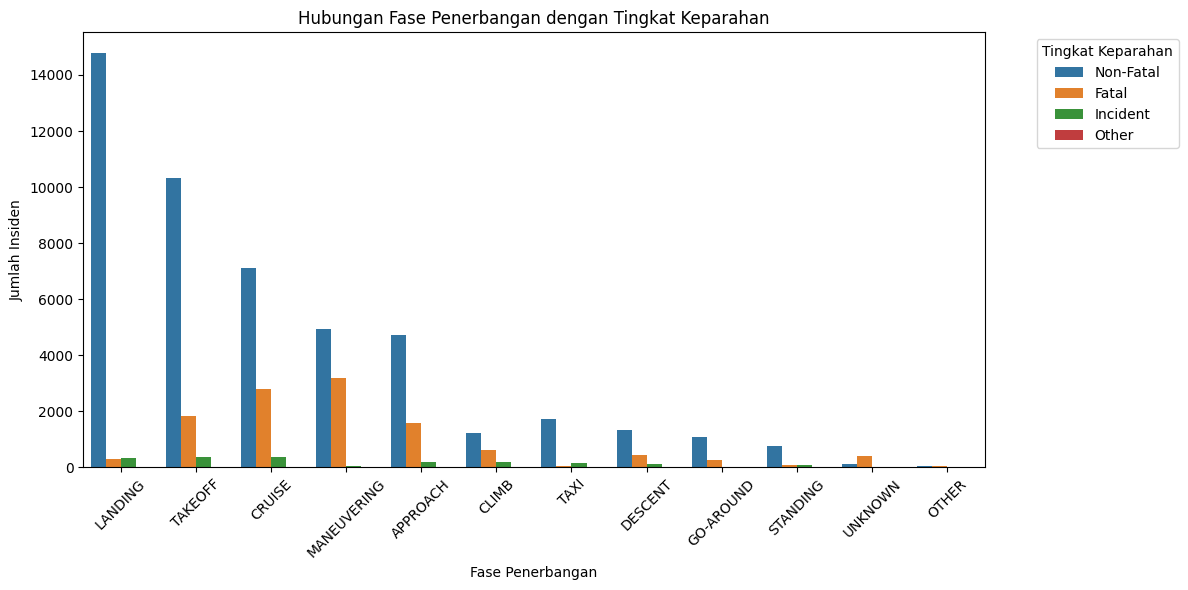

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Broad Phase of Flight', hue='Injury_Severity_Clean',
              order=df['Broad Phase of Flight'].value_counts().index)

plt.title('Hubungan Fase Penerbangan dengan Tingkat Keparahan')
plt.xlabel('Fase Penerbangan')
plt.ylabel('Jumlah Insiden')
plt.xticks(rotation=45)
plt.legend(title='Tingkat Keparahan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<ul>
  <li>
    <strong>Label Encoding (Target):</strong> 
    Terapkan pada variabel <code>Injury_Severity_Clean</code> agar kelasnya berubah menjadi angka diskrit (misal: 0, 1, 2).
  </li>
  <li>
    <strong>One-Hot Encoding (Fitur Kategorikal):</strong> 
    Gunakan <code>pd.get_dummies</code> pada fitur kategorikal lainnya agar tidak ada asumsi tingkatan/jarak antar kategori teks.
  </li>
</ul>


In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Seleksi fitur & Filter 3 kelas utama
features = ['Weather Condition', 'Broad Phase of Flight', 'Aircraft Damage', 'Number of Engines', 'Engine Type', 'Injury_Severity_Clean']
df_model = df[features].copy()
df_model = df_model[df_model['Injury_Severity_Clean'].isin(['Fatal', 'Non-Fatal', 'Incident'])]

# 2. Handling Missing Value (Kategorikal diisi 'Unknown')
kategorikal_cols = ['Weather Condition', 'Broad Phase of Flight', 'Aircraft Damage', 'Engine Type']
for col in kategorikal_cols:
    df_model[col] = df_model[col].fillna('Unknown')

# 3. Handling Missing Value untuk Numerik
df_model['Number of Engines'] = pd.to_numeric(df_model['Number of Engines'], errors='coerce')
modus_engines = df_model['Number of Engines'].mode()[0]
df_model['Number of Engines'] = df_model['Number of Engines'].fillna(modus_engines).astype(int)

# 4. Pisahkan Fitur (X) dan Target (y)
X = df_model.drop(columns=['Injury_Severity_Clean'])
y = df_model['Injury_Severity_Clean']

# 5. Mapping Target ke Angka
target_map = {'Incident': 0, 'Non-Fatal': 1, 'Fatal': 2}
y_encoded = y.map(target_map)

# 6. Fit & Transform menggunakan OneHotEncoder
encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), kategorikal_cols)
    ],
    remainder='passthrough' # 'Number of Engines' tidak di-encode
)

# Transform data fitur X menjadi array numerik
X_encoded_array = encoder.fit_transform(X)

# Dapatkan nama fitur baru hasil encoding
feature_names = encoder.get_feature_names_out()

# Buat DataFrame baru hasil encoding
X_encoded = pd.DataFrame(X_encoded_array, columns=feature_names)

print("--- HASIL ENCODING DENGAN ONEHOTENCODER ---")
print(f"Bentuk data fitur X: {X_encoded.shape}")
print(f"Jumlah Total Fitur: {len(feature_names)}")

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Jumlah Data Training (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Testing (X_test)  : {X_test.shape[0]} baris")

--- HASIL ENCODING DENGAN ONEHOTENCODER ---
Bentuk data fitur X: (150863, 29)
Jumlah Total Fitur: 29
Jumlah Data Training (X_train): 120690 baris
Jumlah Data Testing (X_test)  : 30173 baris


In [13]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# 1. Inisialisasi Model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)

# LinearSVC + CalibratedClassifierCV agar efisien & mendukung predict_proba()
base_svm = LinearSVC(random_state=42, max_iter=2000, dual=False)
svm_model = CalibratedClassifierCV(estimator=base_svm)

# 2. Training Random Forest
print("--- Memulai Training Random Forest ---")
start_time = time.time()
rf_model.fit(X_train, y_train)
print(f"Random Forest selesai dalam: {time.time() - start_time:.2f} detik\n")

# 3. Training XGBoost
print("--- Memulai Training XGBoost ---")
start_time = time.time()
xgb_model.fit(X_train, y_train)
print(f"XGBoost selesai dalam: {time.time() - start_time:.2f} detik\n")

# 4. Training SVM
print("--- Memulai Training SVM ---")
start_time = time.time()
svm_model.fit(X_train, y_train)
print(f"SVM selesai dalam: {time.time() - start_time:.2f} detik\n")

print("--- SEMUA MODEL BERHASIL DILATIH! ---")

--- Memulai Training Random Forest ---
Random Forest selesai dalam: 0.75 detik

--- Memulai Training XGBoost ---
XGBoost selesai dalam: 0.69 detik

--- Memulai Training SVM ---
SVM selesai dalam: 2.43 detik

--- SEMUA MODEL BERHASIL DILATIH! ---


In [14]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'SVM': svm_model
}

summary_metrics = []

print("--- HASIL EVALUASI MODEL ---")
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    summary_metrics.append({'Model': name, 'Accuracy (%)': round(acc*100, 2), 'F1-Score Macro (%)': round(f1_macro*100, 2)})
    
    print(f"\n================ {name} ================")
    print(f"Akurasi Keseluruhan : {acc*100:.2f}%")
    print(f"F1-Score (Macro)    : {f1_macro*100:.2f}%")
    print("\nLaporan Klasifikasi Detail:")
    print(classification_report(y_test, y_pred, target_names=['Incident', 'Non-Fatal', 'Fatal']))

df_summary = pd.DataFrame(summary_metrics)
print("\n--- RINGKASAN PERBANDINGAN MODEL ---")
print(df_summary)

--- HASIL EVALUASI MODEL ---

================ Random Forest ================
Akurasi Keseluruhan : 85.57%
F1-Score (Macro)    : 66.71%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

    Incident       0.81      0.48      0.61       730
   Non-Fatal       0.87      0.97      0.92     24414
       Fatal       0.72      0.36      0.48      5029

    accuracy                           0.86     30173
   macro avg       0.80      0.60      0.67     30173
weighted avg       0.84      0.86      0.84     30173


================ XGBoost ================
Akurasi Keseluruhan : 85.58%
F1-Score (Macro)    : 66.79%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

    Incident       0.80      0.49      0.61       730
   Non-Fatal       0.87      0.97      0.92     24414
       Fatal       0.73      0.36      0.48      5029

    accuracy                           0.86     30173
   macro avg       0.80      0.61      0.67     3017

In [15]:
print("--- FAKTOR DOMINAN BERDASARKAN RANDOM FOREST ---")
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

# Ambil 5 besar faktor paling dominan
print("5 Faktor Paling Dominan Mempengaruhi Fatalitas:")
for i in range(5):
    print(f"{i+1}. {X_encoded.columns[indices_rf[i]]} (Skor: {importances_rf[indices_rf[i]]:.4f})")

print("\n--- FAKTOR DOMINAN BERDASARKAN XGBOOST ---")
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

print("5 Faktor Paling Dominan Mempengaruhi Fatalitas:")
for i in range(5):
    print(f"{i+1}. {X_encoded.columns[indices_xgb[i]]} (Skor: {importances_xgb[indices_xgb[i]]:.4f})")

--- FAKTOR DOMINAN BERDASARKAN RANDOM FOREST ---
5 Faktor Paling Dominan Mempengaruhi Fatalitas:
1. cat__Aircraft Damage_Destroyed (Skor: 0.3372)
2. cat__Aircraft Damage_Substantial (Skor: 0.1625)
3. cat__Aircraft Damage_Minor (Skor: 0.0788)
4. cat__Aircraft Damage_Unknown (Skor: 0.0557)
5. cat__Weather Condition_IMC (Skor: 0.0497)

--- FAKTOR DOMINAN BERDASARKAN XGBOOST ---
5 Faktor Paling Dominan Mempengaruhi Fatalitas:
1. cat__Aircraft Damage_Destroyed (Skor: 0.4545)
2. cat__Aircraft Damage_Minor (Skor: 0.1034)
3. cat__Weather Condition_Unknown (Skor: 0.0779)
4. cat__Aircraft Damage_Substantial (Skor: 0.0754)
5. cat__Weather Condition_VMC (Skor: 0.0685)


<Figure size 800x600 with 0 Axes>

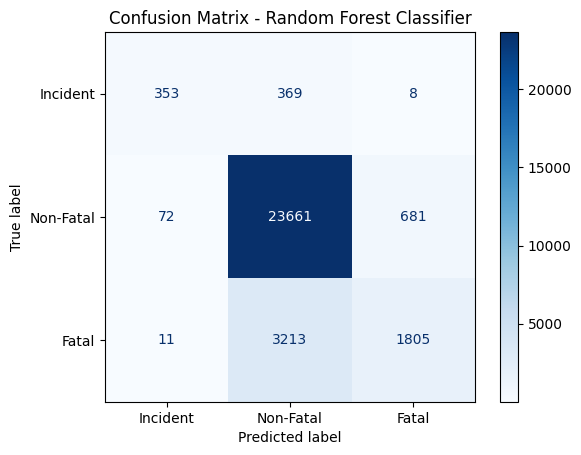

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Kita pilih Random Forest atau XGBoost sebagai representasi (misal: Random Forest)
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

# Visualisasi Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incident', 'Non-Fatal', 'Fatal'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Random Forest Classifier')
plt.grid(False) # Mematikan grid lines agar matriks bersih
plt.show()

C:\Users\Ghally\AppData\Local\Temp\ipykernel_38956\3246429573.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


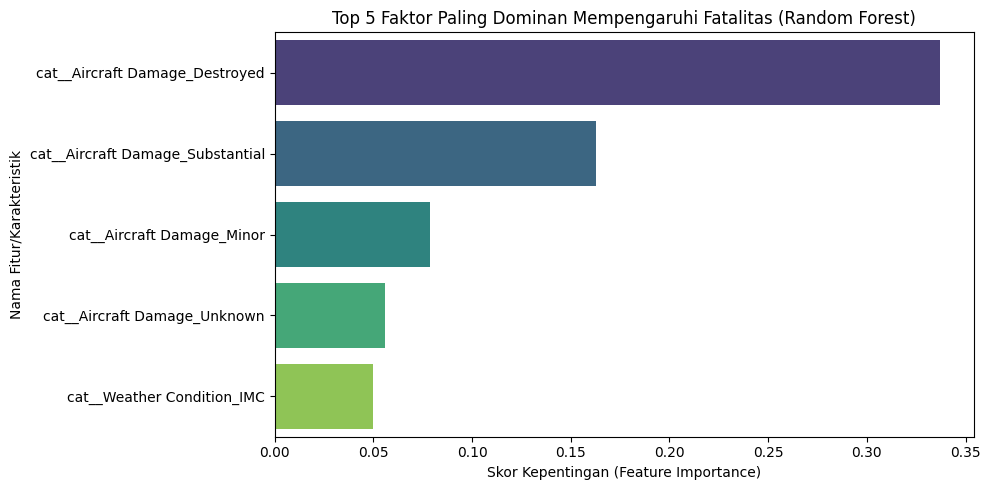

In [17]:
# Cell Tambahan: Visualisasi Faktor Dominan
plt.figure(figsize=(10, 5))

# Mengambil top 5 fitur dari Random Forest
top_features = [X_encoded.columns[indices_rf[i]] for i in range(5)]
top_scores = [importances_rf[indices_rf[i]] for i in range(5)]

# Plot grafik batang
sns.barplot(x=top_scores, y=top_features, palette='viridis')

plt.title('Top 5 Faktor Paling Dominan Mempengaruhi Fatalitas (Random Forest)')
plt.xlabel('Skor Kepentingan (Feature Importance)')
plt.ylabel('Nama Fitur/Karakteristik')
plt.tight_layout()
plt.show()

In [18]:
import pickle

# 1. Ekspor Model XGBoost
with open("model_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# 2. Ekspor Model Random Forest
with open("model_random_forest.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# 3. Ekspor Model SVM
with open("model_svm.pkl", "wb") as f:
    pickle.dump(svm_model, f)

# 4. EKSPOR ENCODER (PENTING AGAR APP.PY TINGGAL MELAKUKAN TRANSFORM)
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("✅ SEMUA MODEL DAN ENCODER BERHASIL DIEKSPOR SINKRON!")

✅ SEMUA MODEL DAN ENCODER BERHASIL DIEKSPOR SINKRON!


In [19]:
print("Jumlah baris data training:", X_train.shape[0])
print("Jumlah fitur setelah One-Hot Encoding:", X_train.shape[1])

Jumlah baris data training: 120690
Jumlah fitur setelah One-Hot Encoding: 29
